In [1]:
import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [66]:
import os
!pip install -Uqq fastai duckduckgo_search

In [4]:
from duckduckgo_search import DDGS 
from fastcore.all import *

def search_images(term, max_images=30):
    print(f"Searching for {term}...")
    with DDGS() as ddgs: 
        imgs = ddgs.images(term, max_results=max_images) 
        results = [r['thumbnail'] for r in imgs]
        return results

In [5]:
urls = search_images('alex ferguson happy')
urls[0]

Searching for alex ferguson happy...


'https://tse2.mm.bing.net/th?id=OIP.ae0BNWC6D3nPYhBgs-U6eQHaEK&pid=Api'

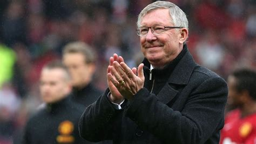

In [7]:
from fastdownload import download_url 
dest = 'happy_alex.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import * 
im = Image.open(dest)
im.to_thumb(256, 256)

Searching for alex ferguson unhappy...
['https://tse3.mm.bing.net/th?id=OIP.A6nNvLIroSBiRdXSsc6y5wHaEK&pid=Api']


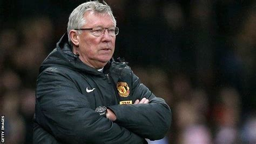

In [58]:
download_url(search_images('alex ferguson unhappy', max_images=1)[0], 'unhappy_alex.jpg', show_progress=False)
Image.open('unhappy_alex.jpg').to_thumb(256, 256)

In [28]:
searches = 'alex ferguson happy', 'alex ferguson unhappy'
path = Path('is_alex_happy')
from time import sleep 

def get_images(keyword, dest): 
        _urls = search_images(keyword) 
        keyword = keyword.replace(' ', '_')
       
        i = 0
        while i < len(_urls): 
                fileName = f'{keyword}_{i}.jpg'
                filePath = dest/fileName
                print(fileName)
                download_url(_urls[i], filePath, show_progress=False)
                i += 1

for o in searches: 
        dest = (path/o.replace(' ', '_'))
        dest.mkdir(exist_ok=True, parents=True)
        get_images(f'{o} photo', dest)
        sleep(10) 
        get_images(f'{o} rain photo', dest)
        sleep(10)
        get_images(f'{o} sunny photo', dest)    
        sleep(10)


Searching for alex ferguson happy photo...
alex_ferguson_happy_photo_0.jpg
alex_ferguson_happy_photo_1.jpg
alex_ferguson_happy_photo_2.jpg
alex_ferguson_happy_photo_3.jpg
alex_ferguson_happy_photo_4.jpg
alex_ferguson_happy_photo_5.jpg
alex_ferguson_happy_photo_6.jpg
alex_ferguson_happy_photo_7.jpg
alex_ferguson_happy_photo_8.jpg
alex_ferguson_happy_photo_9.jpg
alex_ferguson_happy_photo_10.jpg
alex_ferguson_happy_photo_11.jpg
alex_ferguson_happy_photo_12.jpg
alex_ferguson_happy_photo_13.jpg
alex_ferguson_happy_photo_14.jpg
alex_ferguson_happy_photo_15.jpg
alex_ferguson_happy_photo_16.jpg
alex_ferguson_happy_photo_17.jpg
alex_ferguson_happy_photo_18.jpg
alex_ferguson_happy_photo_19.jpg
alex_ferguson_happy_photo_20.jpg
alex_ferguson_happy_photo_21.jpg
alex_ferguson_happy_photo_22.jpg
alex_ferguson_happy_photo_23.jpg
alex_ferguson_happy_photo_24.jpg
alex_ferguson_happy_photo_25.jpg
alex_ferguson_happy_photo_26.jpg
alex_ferguson_happy_photo_27.jpg
alex_ferguson_happy_photo_28.jpg
alex_fergu

In [24]:
# failed = verify_images(get_image_files(path)) 
# failed.map(Path.unlink)
# len(failed)

jvdImages = get_image_files(path)
print(jvdImages)

[Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_0.jpg'), Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_1.jpg'), Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_10.jpg'), Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_2.jpg'), Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_3.jpg'), Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_4.jpg'), Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_5.jpg'), Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_6.jpg'), Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_7.jpg'), Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_8.jpg'), Path('is_alex_happy/alex_ferguson_happy/alex_ferguson_happy_photo_9.jpg')]


In [27]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)